In [1]:
# Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# kNN 
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Cross Validation for Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Pipeline
from sklearn.pipeline import Pipeline

In [2]:
iris_df = pd.read_csv("Iris.csv")

In [3]:
iris_df.info()
iris_df.shape
iris_df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
107,108,7.3,2.9,6.3,1.8,Iris-virginica
93,94,5.0,2.3,3.3,1.0,Iris-versicolor
81,82,5.5,2.4,3.7,1.0,Iris-versicolor
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
62,63,6.0,2.2,4.0,1.0,Iris-versicolor


In [4]:
# Check for missing Values
missing = pd.DataFrame({
    "Missing_Count": iris_df.isnull().sum(),
    "Missing_%": (iris_df.isnull().sum()/len(iris_df))*100
})
missing_val = missing[missing["Missing_Count"]>0]

print ("No missing values found!") if missing_val.empty else missing_val

No missing values found!


In [5]:
# Check for Duplicate Rows
duplicates = iris_df.duplicated().sum()

if duplicates > 0:
    duplicate_rows = df.duplicated()
    print(duplicate_rows)
    iris_df.drop_duplicates(inplace=True)
else:
    print("No Duplicates found!")

if duplicates > 0:
    iris_df.reset_index()

No Duplicates found!


In [6]:
# Check for datatypes
iris_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
# Check for unique values in categorical columns
for col in iris_df.select_dtypes(include="object"):
    print("Column:", col)
    print("Unique Values:", iris_df[col].nunique())
    print(iris_df[col].value_counts())
    print("*"*127)

Column: Species
Unique Values: 3
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
*******************************************************************************************************************************


In [8]:
# Fix Column names & Column data
iris_df.columns = iris_df.columns.str.strip()

for col in iris_df.select_dtypes(include="object"):
    iris_df[col] = iris_df[col].str.strip()

# Feature Selection
iris_df.drop(columns=["Id"], inplace=True) # Drop Id column

# Feature Engineering
le = LabelEncoder()
iris_df['Species'] = le.fit_transform(iris_df['Species'])
print(le.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [9]:
# Get a Summary of the dataset
iris_df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
iris_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
# Classifying Inputs & Outputs
X = iris_df.drop(columns=["Species"])
y = iris_df["Species"]

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Logistic Regression

# Model Training
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
# Naive Bayes Algorithm

# Model Training
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb

,priors,None
,var_smoothing,1e-09


In [14]:
# kNN

# Creating Pipeline & performing Cross Validation for Hyperparameter Tuning
pipeline = Pipeline([ 
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {"knn__n_neighbors": [3, 5, 7, 9]}

ClassifierCV = GridSearchCV(
    pipeline,
    param_grid,
    cv = 5
)

# Model Training
ClassifierCV.fit(X_train,y_train)
ClassifierCV

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [15]:
result = pd.DataFrame(ClassifierCV.cv_results_)
res = result[["params", "mean_test_score", "rank_test_score"]]
res

,params,mean_test_score,rank_test_score
0,{'knn__n_neighbors': 3},0.950000,1
1,{'knn__n_neighbors': 5},0.933333,4
2,{'knn__n_neighbors': 7},0.941667,2
3,{'knn__n_neighbors': 9},0.941667,2


In [16]:
# Evaluation Metrics
models = {
    "Logistic Regression": lr,
    "Naive Bayes": gnb,
    "kNN": ClassifierCV
}

for key, model in models.items():
    print(key)
    y_pred = model.predict(X)
    
    print("Accuracy:", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred, average="macro"))
    print("Recall:", recall_score(y, y_pred, average="macro"))
    print("f1 Score:", f1_score(y, y_pred, average="macro"))
    print("*"*127)   

Logistic Regression
Accuracy: 0.98
Precision: 0.9811320754716982
Recall: 0.98
f1 Score: 0.9799819837854069
*******************************************************************************************************************************
Naive Bayes
Accuracy: 0.96
Precision: 0.96
Recall: 0.96
f1 Score: 0.96
*******************************************************************************************************************************
kNN
Accuracy: 0.9533333333333334
Precision: 0.9534480458850206
Recall: 0.9533333333333333
f1 Score: 0.9533286661999533
*******************************************************************************************************************************


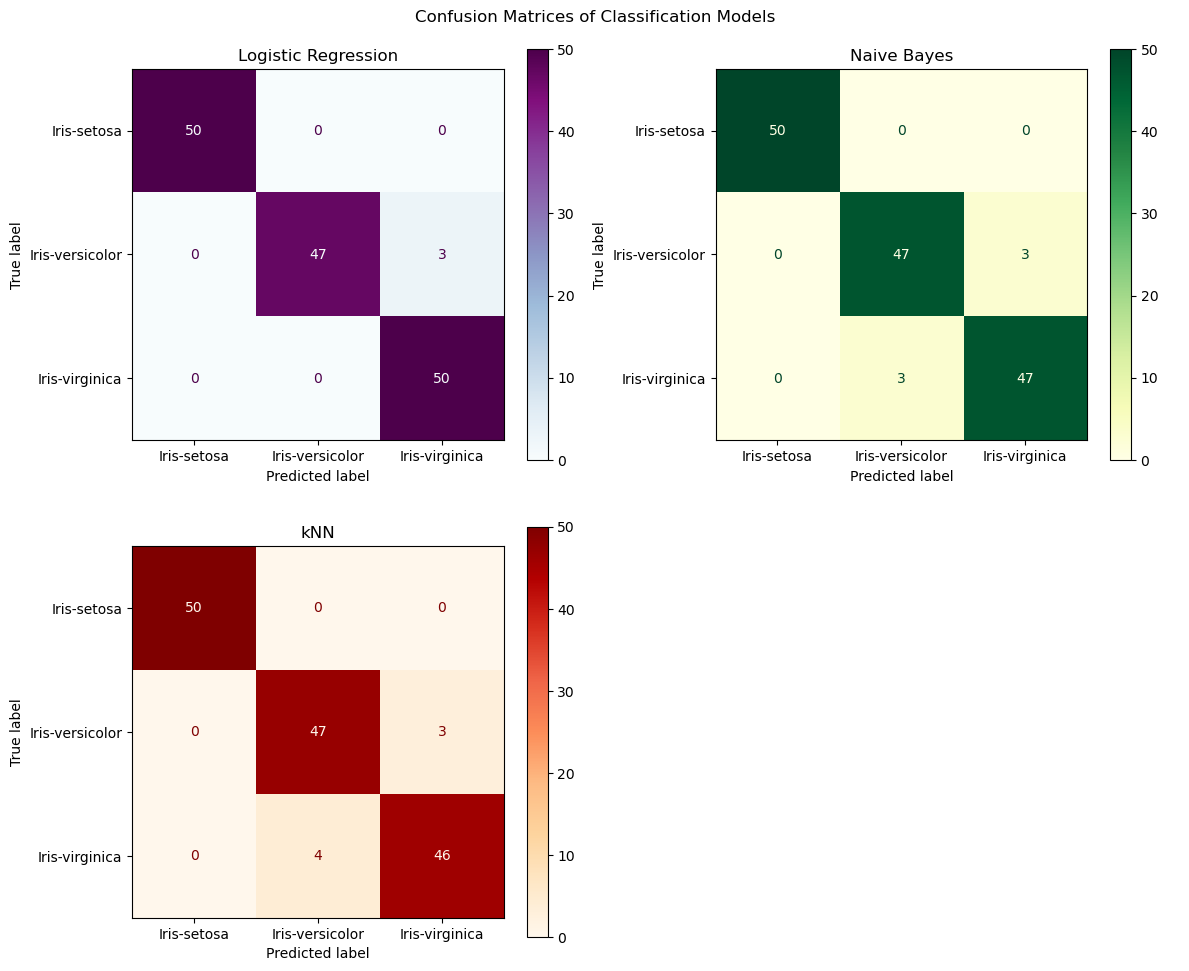

In [17]:
# Confusion Matrix
models = {
    "Logistic Regression": lr,
    "Naive Bayes": gnb,
    "kNN": ClassifierCV
}
class_names = le.classes_
cmaps = ["BuPu", "YlGn", "OrRd"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()  # Flatten 2D array into 1D

for i, (name, model) in enumerate(models.items()):

    # Predict on the whole dataset
    y_pred = model.predict(X)

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred,
        display_labels=class_names,
        cmap=cmaps[i],
        colorbar=True,
        ax=axes[i]
    )

    axes[i].set_title(name)

# Hide the unused subplot
axes[3].axis("off")

plt.suptitle("Confusion Matrices of Classification Models")
    
plt.tight_layout()
plt.show()

In [18]:
# Classification Report for Logistic Regression

report = classification_report(
    y,
    lr.predict(X),
    target_names=["Setosa", "Versicolor", "Virginica"],
    output_dict=True
)

print()

print("="*45)
print("Classification Report (Logistic Regression)")
print("="*45)
report_df = pd.DataFrame(report).transpose()
report_df


Classification Report (Logistic Regression)


,precision,recall,f1-score,support
Setosa,1.000000,1.00,1.000000,50.00
Versicolor,1.000000,0.94,0.969072,50.00
Virginica,0.943396,1.00,0.970874,50.00
accuracy,0.980000,0.98,0.980000,0.98
macro avg,0.981132,0.98,0.979982,150.00
weighted avg,0.981132,0.98,0.979982,150.00


In [19]:
# Classification Report for Naive Bayes

report = classification_report(
    y,
    gnb.predict(X),
    target_names=["Setosa", "Versicolor", "Virginica"],
    output_dict=True
)

print()

print("="*45)
print("Classification Report (Naive Bayes)")
print("="*45)
report_df = pd.DataFrame(report).transpose()
report_df


Classification Report (Naive Bayes)


,precision,recall,f1-score,support
Setosa,1.00,1.00,1.00,50.00
Versicolor,0.94,0.94,0.94,50.00
Virginica,0.94,0.94,0.94,50.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.96,0.96,150.00
weighted avg,0.96,0.96,0.96,150.00


In [20]:
# Classification Report for kNN

report = classification_report(
    y,
    ClassifierCV.predict(X),
    target_names=["Setosa", "Versicolor", "Virginica"],
    output_dict=True
)

print()

print("="*45)
print("Classification Report (kNN)")
print("="*45)
report_df = pd.DataFrame(report).transpose()
report_df


Classification Report (kNN)


,precision,recall,f1-score,support
Setosa,1.000000,1.000000,1.000000,50.000000
Versicolor,0.921569,0.940000,0.930693,50.000000
Virginica,0.938776,0.920000,0.929293,50.000000
accuracy,0.953333,0.953333,0.953333,0.953333
macro avg,0.953448,0.953333,0.953329,150.000000
weighted avg,0.953448,0.953333,0.953329,150.000000
